# Introduction

In this notebook, I will iterate on the target. I want to understand better what is going on term of WS and WS48 in the NBA. Which one should I take ? And why ? 
But also, is it something else that I need to consider ? 

Question that I want to answer in my thesis:
* Does the player is impactful ? 
* Does the player bring wins to the team ? 

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
HOME = r"C:\Users\Utilisateur\Desktop\Master ULB\Mémoire"
DB = r"\Database"
CODE = r"\Thesis - Code"

In [21]:
NBA_PATH = HOME + DB + r"\NBA\Stats 2000 to 2024\Regular Season.xlsx"
nba = pd.read_excel(NBA_PATH)

In [ ]:
nba

## Year counting

**First problem**, I don't have a column that count the number of season that a player has played. Thus, I can't say if it is the player's second year in the league or not. 

**My solution**, take the 2000 NBA Draft as threshold (because in my DB there are players from 2001 to 2025) and thereafter count the number of time the player appears. If he wasn't drafted in 2000 he by definition have at least one season in 2000.

In [22]:
DRAFT_2000 = HOME + DB + r"\NBA\Draft Picks 2000 to 2024\NBA Draft Picks 2000.csv"
draft = pd.read_csv(DRAFT_2000)

In [23]:
nba[(nba['Player'] == draft['Player'][0])]['season']

90       1
592      2
1088     3
1569     4
2176     5
2788     6
3430     7
3878     8
4518     9
5086    10
5759    11
6472    12
6943    13
7660    14
8491    15
Name: season, dtype: int64

In [24]:
def add_years_played(nba_data, draft_data):
    """
    Add 'yrs' column to nba_data indicating years played, where:
    - Players drafted BEFORE 2000 start at yrs=2 in 2000 season
    - Players drafted IN 2000 start at yrs=1 in their rookie season
    - Players drafted AFTER 2000 follow normal counting (yrs=1 in first season)
    """
    # Create a set of players drafted in 2000
    drafted_2000 = set(draft_data['Player'].unique())
    
    # Find all players and their first seasons
    player_first_season = nba_data.groupby('Player')['season'].min().to_dict()
    
    # Adjust first season for pre-2000 players
    for player, first_season in player_first_season.items():
        if player not in drafted_2000 and first_season == 1:
            # This player started before 2000 (since their first season is 2000-01)
            player_first_season[player] = 0  # Will make 2000 season count as yrs=2
    
    # Calculate years played
    nba_data['yrs'] = nba_data.apply(
        lambda row: row['season'] - player_first_season.get(row['Player'], row['season']) + 1,
        axis=1
    )
    
    return nba_data

In [25]:
nba_data = add_years_played(nba, draft)

As a result of the function, we have a database containing the column 'yrs' which give the number of years that a player has been in the League.

Another solution could consist of doing it manually for players during the season 2000-2001.

## Descriptive analysis on the WS

### Trend understanding

Firstly, I want to have at the overall evolution of the WS and the WS48 over the years. Where each player is a path and each step is a season.

In [30]:
df = nba_data.copy()
# 1. Créer un DataFrame artificiel pour t=0
df_origin = pd.DataFrame({
    'Player': df['Player'].unique(),
    'yrs': 0,
    'WS': 0,
    'WS/48': 0
})


# 2. Concaténer avec les données réelles
df_with_origin = pd.concat([df_origin, df], ignore_index=True).sort_values(['Player', 'yrs'])

# 3. Filtrer les joueurs avec moins de X saisons (optionnel)
min_seasons = 0
player_counts = df_with_origin['Player'].value_counts()
valid_players = player_counts[player_counts >= min_seasons].index
df_filtered = df_with_origin[df_with_origin['Player'].isin(valid_players)]


In [ ]:
df_filtered = df_with_origin[(df_with_origin['season']>8) & (df_with_origin['season']>8)]
df_with_origin = pd.concat([df_origin, df_filtered], ignore_index=True).sort_values(['Player', 'yrs'])

In [14]:
df_with_origin = df_with_origin[(df_with_origin['WS/48'] < 1) & (df_with_origin['WS/48'] > -1)]

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_15168\93837771.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(data=df_with_origin, x='yrs', y='WS/48',


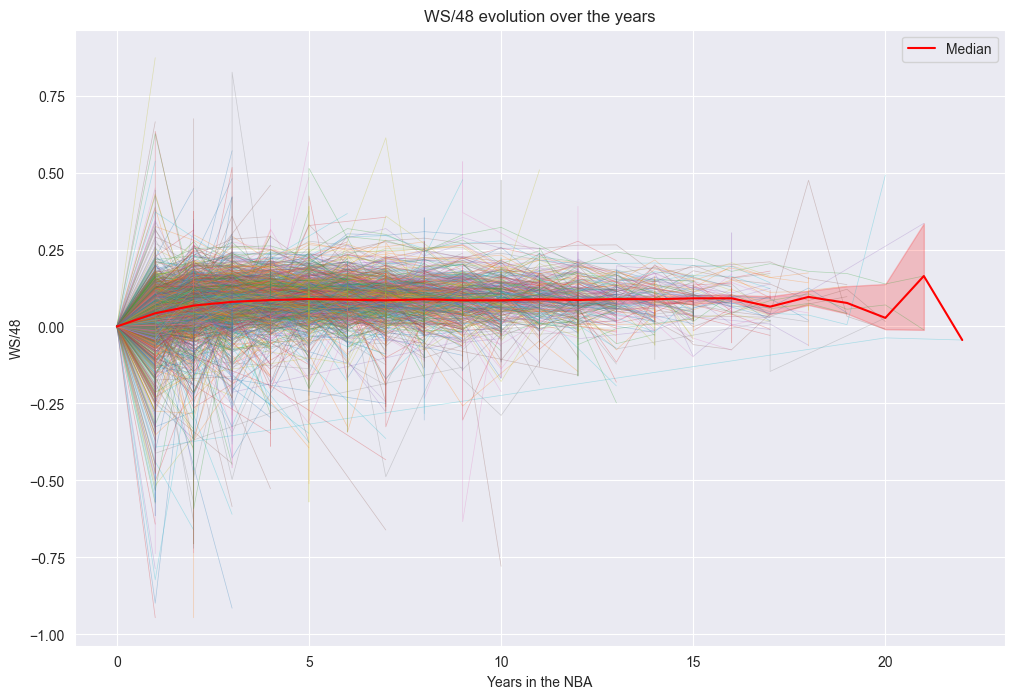

In [17]:
# 4. Visualisation
plt.figure(figsize=(12, 8))
sns.set_style("darkgrid")

# Tracer chaque trajectoire
for player in df_with_origin['Player'].unique():
    player_data = df_with_origin[df_with_origin['Player'] == player]
    plt.plot(player_data['yrs'], player_data['WS/48'],
            alpha=0.3, linewidth=0.5)

# Ajouter des statistiques agrégées
sns.lineplot(data=df_with_origin, x='yrs', y='WS/48', 
             ci=95, color='red', 
             estimator='median', label='Median')

plt.title('WS/48 evolution over the years')
plt.xlabel('Years in the NBA')
plt.ylabel('WS/48')
plt.legend()
plt.show()

In [32]:
df_filtered = df_with_origin[(df_with_origin['season']>4)]

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_15168\169566325.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 99)` for the same effect.

  sns.lineplot(data=df_filtered, x='yrs', y='WS/48',
C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_15168\169566325.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 99)` for the same effect.

  sns.lineplot(data=df_with_origin, x='yrs', y='WS/48',


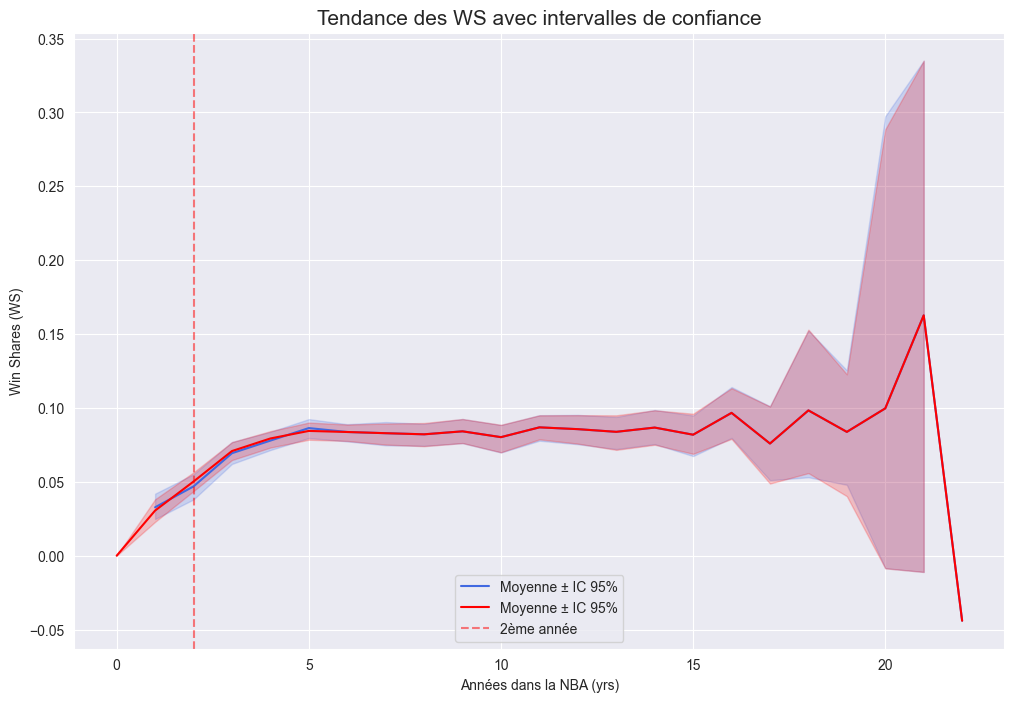

In [33]:
plt.figure(figsize=(12, 8))
sns.lineplot(data=df_filtered, x='yrs', y='WS/48', 
             ci=99,  # Intervalle de confiance à 95%
             estimator='mean', 
             color='royalblue',
             label='Moyenne ± IC 95%')
sns.lineplot(data=df_with_origin, x='yrs', y='WS/48', 
             ci=99,  # Intervalle de confiance à 95%
             estimator='mean', 
             color='red',
             label='Moyenne ± IC 95%')

plt.title('Tendance des WS avec intervalles de confiance', fontsize=15)
plt.xlabel('Années dans la NBA (yrs)')
plt.ylabel('Win Shares (WS)')
plt.axvline(x=2, linestyle='--', color='red', alpha=0.5, label='2ème année')
plt.legend()
plt.show()

RuntimeError: No mappable was found to use for colorbar creation. First define a mappable such as an image (with imshow) or a contour set (with contourf).

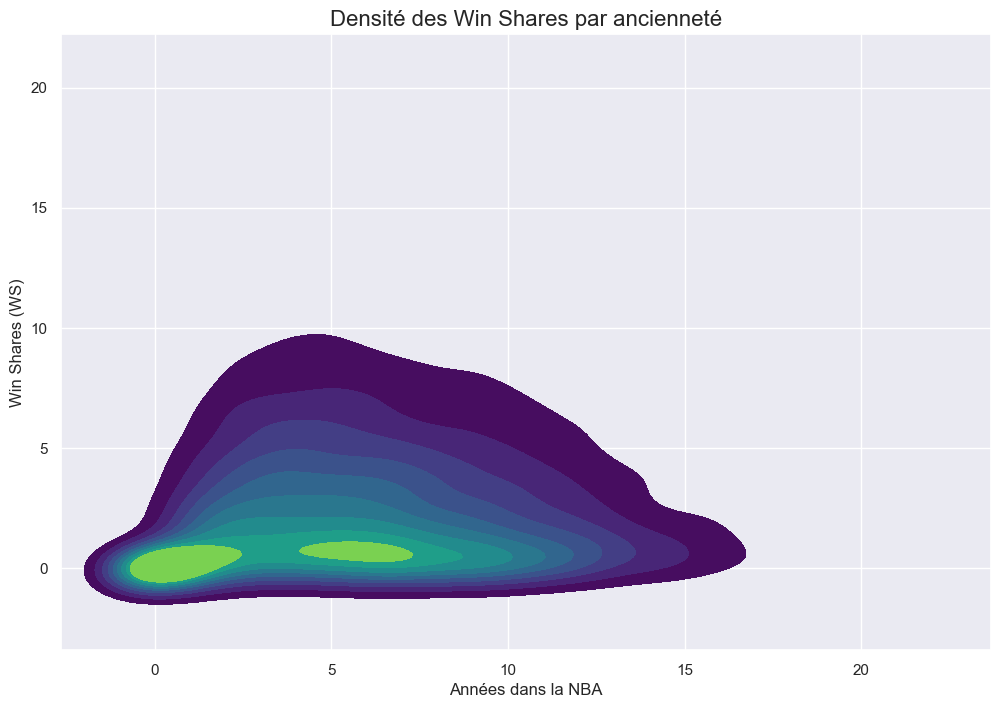

In [49]:
plt.figure(figsize=(12, 8))
sns.kdeplot(data=df_filtered, x='yrs', y='WS', 
            cmap='viridis', fill=True, thresh=0.1)
plt.title('Densité des Win Shares par ancienneté', fontsize=16)
plt.xlabel('Années dans la NBA', fontsize=12)
plt.ylabel('Win Shares (WS)', fontsize=12)
plt.colorbar(label='Densité')
plt.show()

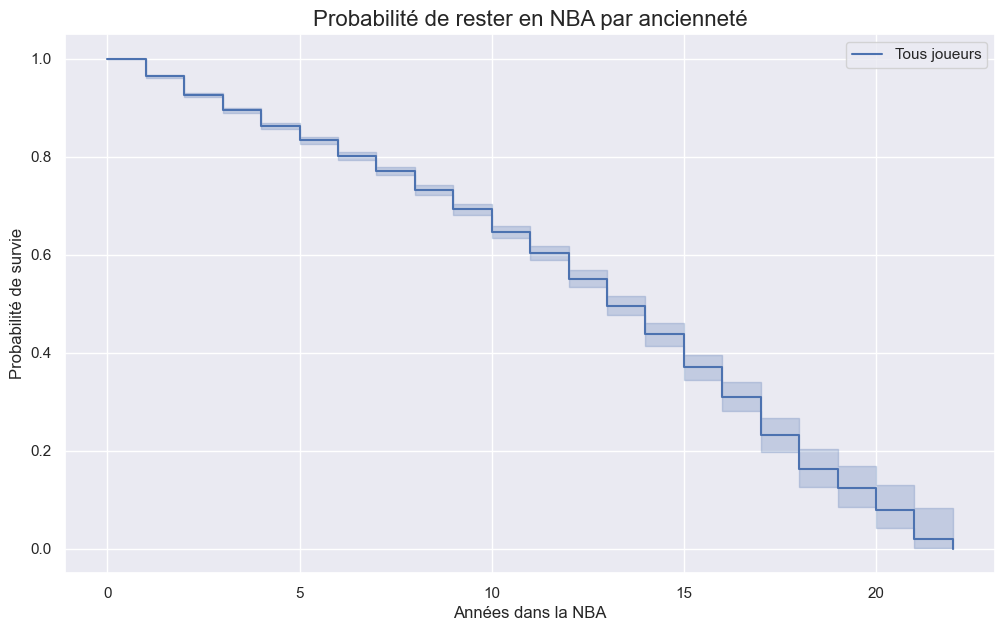

In [57]:
from lifelines import KaplanMeierFitter

# Créer une variable binaire "toujours en activité"
df['active'] = (df['yrs'] == df.groupby('Player')['yrs'].transform('max'))

kmf = KaplanMeierFitter()
kmf.fit(df['yrs'], df['active'], label='Tous joueurs')

plt.figure(figsize=(12, 7))
kmf.plot_survival_function()
plt.title('Probabilité de rester en NBA par ancienneté', fontsize=16)
plt.xlabel('Années dans la NBA', fontsize=12)
plt.ylabel('Probabilité de survie', fontsize=12)
plt.grid(True)
plt.show()

### Distribution

Firstly, I want to see how WS and WS48 is distributed among all the players that I have. Then I want to have a look at the distribution for players in their second year. However, we exclude the 2000-01 season because it is biased. 

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_15168\1862120497.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


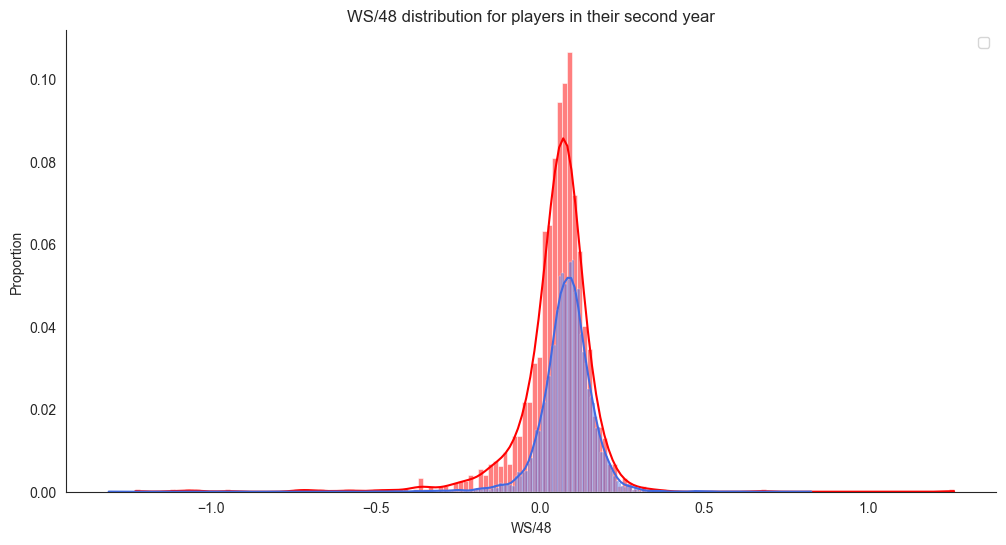

In [36]:
cond = True
target = 'WS/48'
#For all the players
plt.figure(figsize=(12, 6))
sns.set_style("white")
if cond:
    sns.histplot(data=nba_data[(nba_data['yrs'] == 2) &
                           (nba_data['season'] > 5)], x=f'{target}', 
                           stat='probability',
                           color='red', 
                           kde = True)
    sns.histplot(data=nba_data[(nba_data['yrs'] > 2) &
                           (nba_data['season'] > 5)], x=f'{target}', 
                           stat='probability',
                           color='royalblue', 
                           kde = True)
    plt.legend()
    
else:
    sns.histplot(data=nba_data, x=f'{target}', 
                           stat='frequence',
                           color='royalblue', 
                           kde = True)

plt.title(f"{target} distribution for players in their second year")
plt.ylabel("Proportion")
sns.despine()

In [93]:
nba_data[(nba_data['yrs'] == 2) &
        (nba_data['season'] != 1) &
        (nba_data['WS/48'] < 0)].shape

(340, 211)

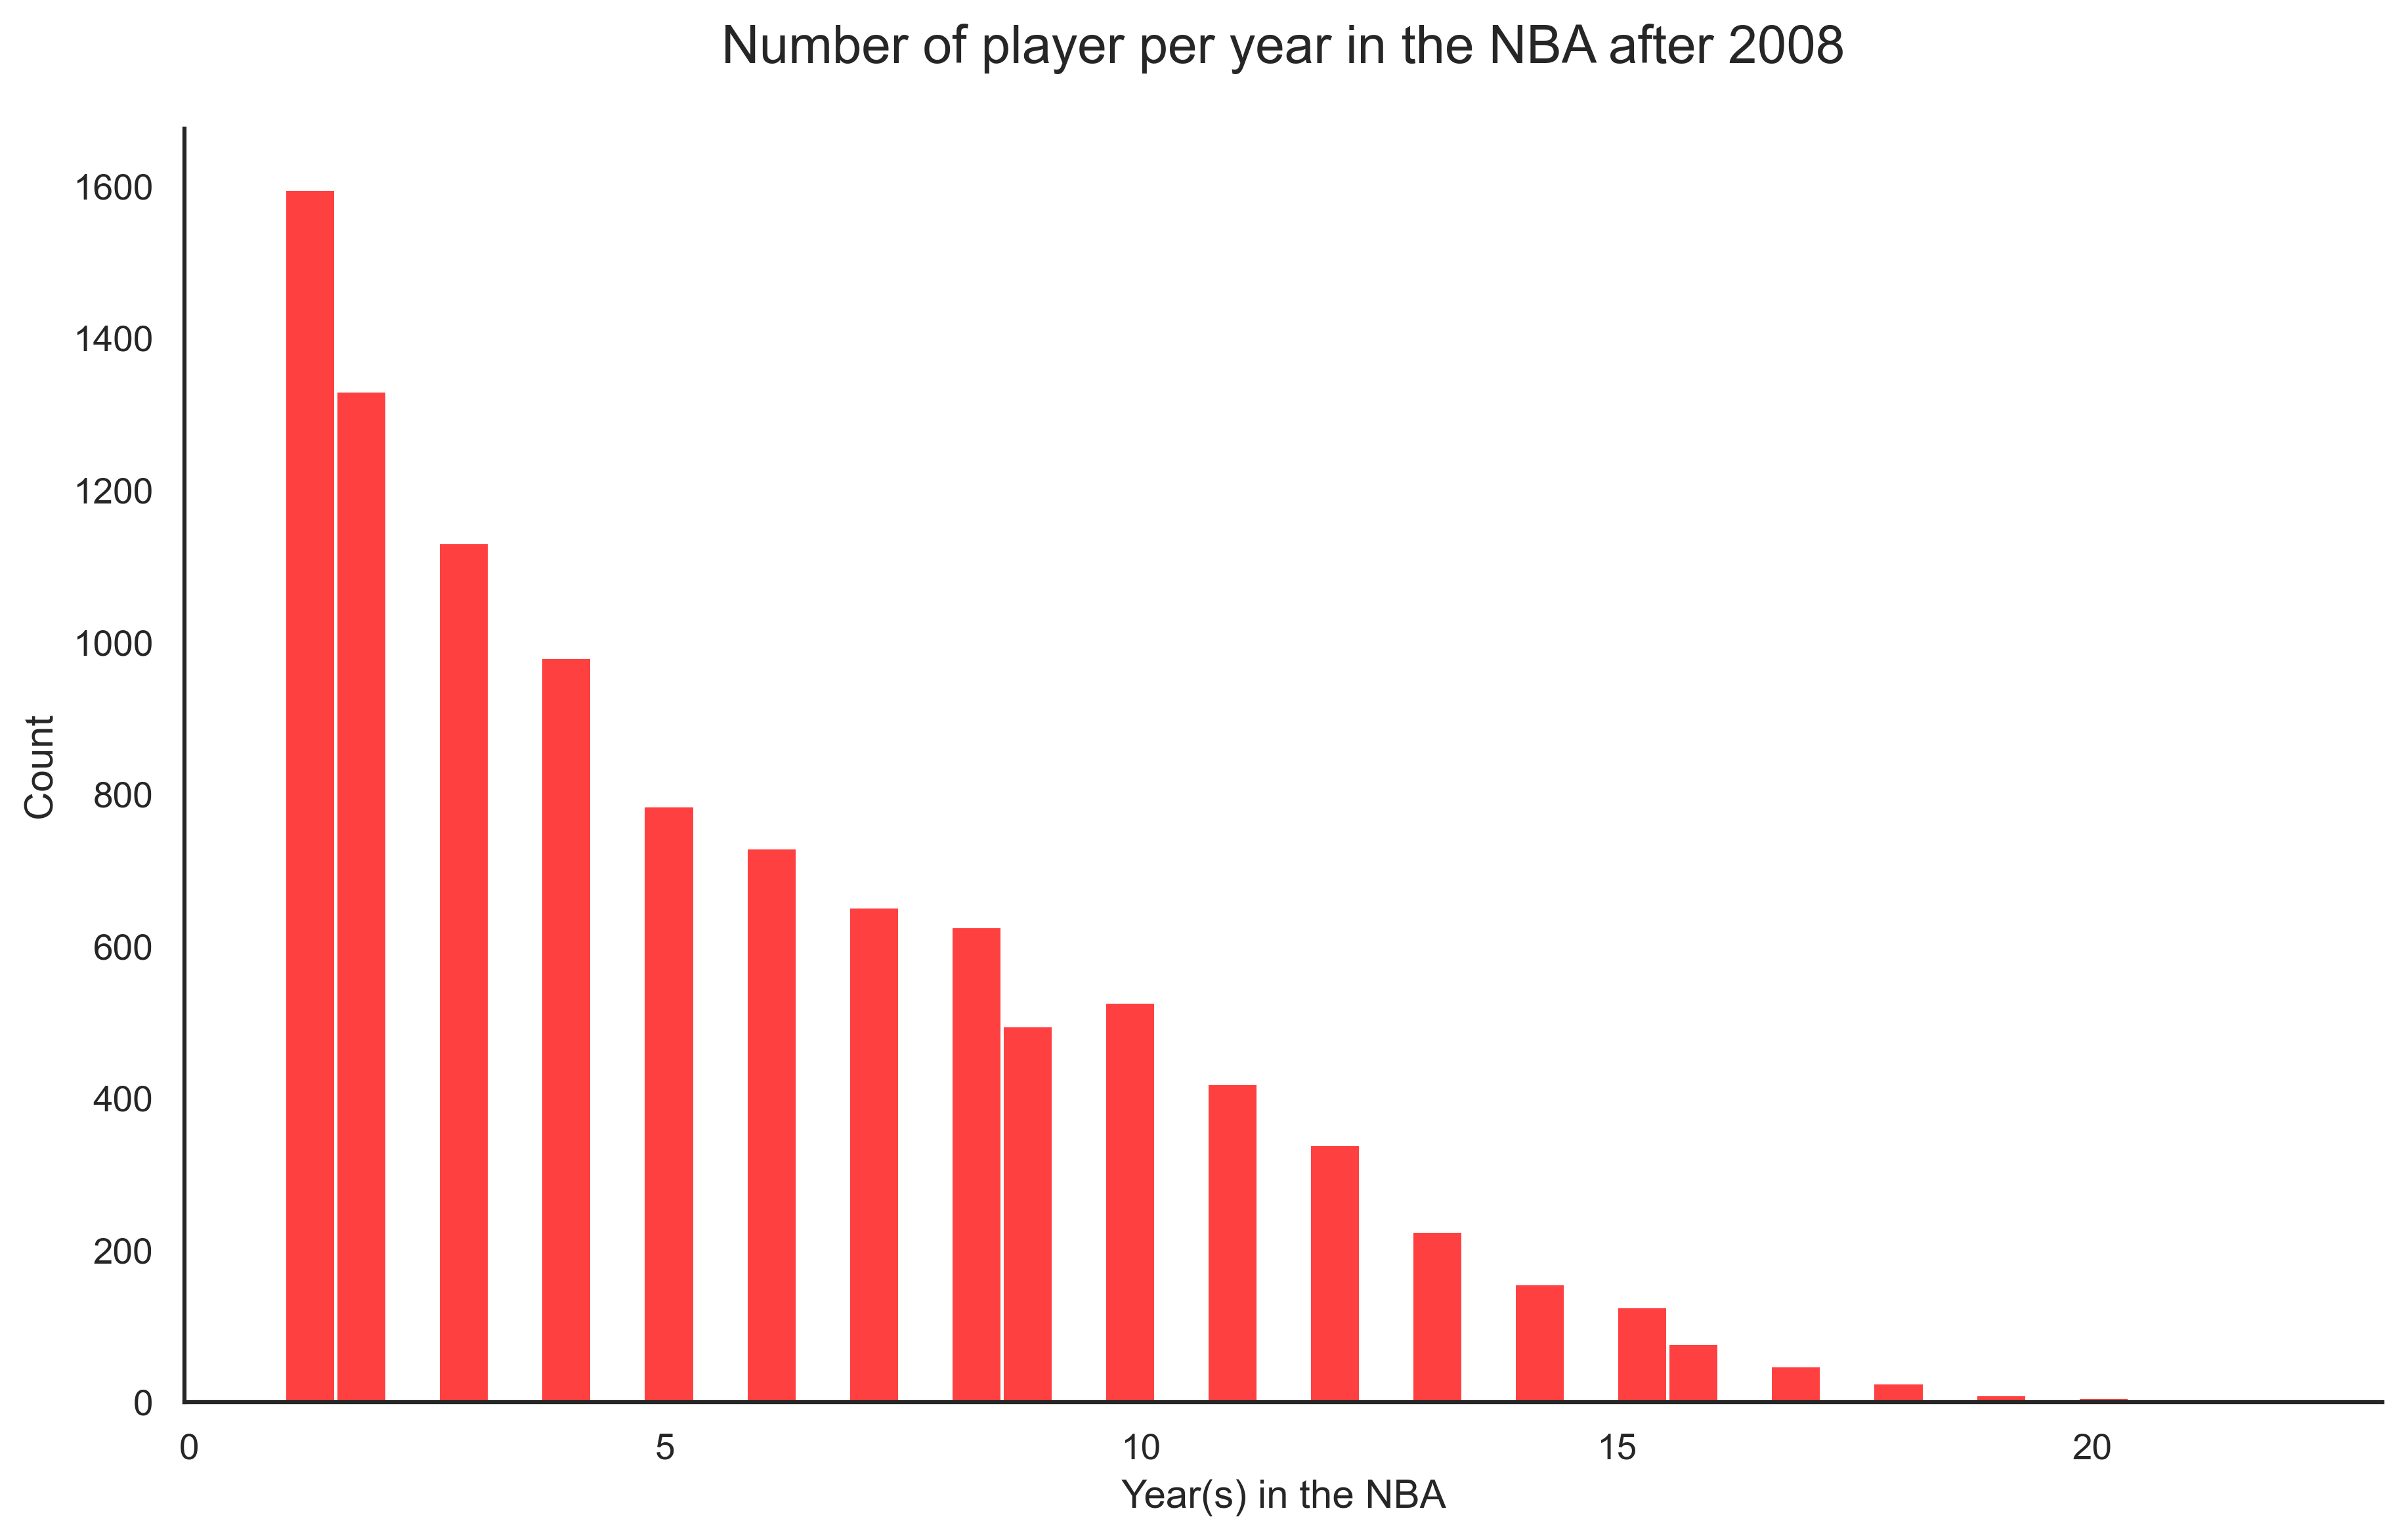

In [135]:
target = 'yrs'
cond = 8
plt.figure(figsize=(12, 7), dpi=360)
sns.set_style("white")
sns.histplot(data=nba_data[(nba_data['season'] > cond)], x=f'{target}', 
                           stat='count',
                           color='red', 
                           kde = False)

plt.title(f"Number of player per year in the NBA after 200{cond}", size=16, pad=20)
plt.xlabel("Year(s) in the NBA")
sns.despine()

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_11616\2539102979.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




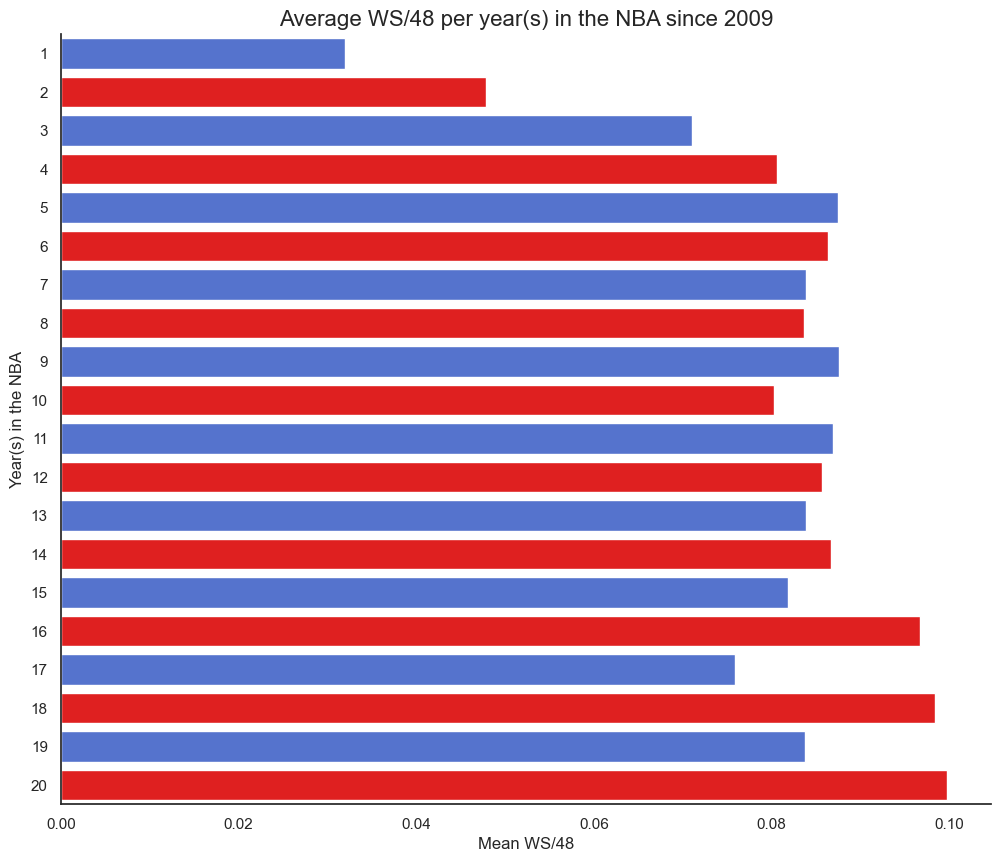

In [233]:
y = 'WS/48'
plt.figure(figsize=(12, 10), dpi=100)
sns.barplot(nba_data[(nba_data['yrs'] < 21) & (nba_data['season'] > 8)].groupby('yrs')[y].mean(), 
            palette=['royalblue', 'red']*10, orient='h', width=0.8)
plt.ylabel('Year(s) in the NBA')
plt.xlabel(f'Mean {y}')
plt.title(f'Average {y} per year(s) in the NBA since 2009', size=16)
sns.despine()

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_11616\781761701.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




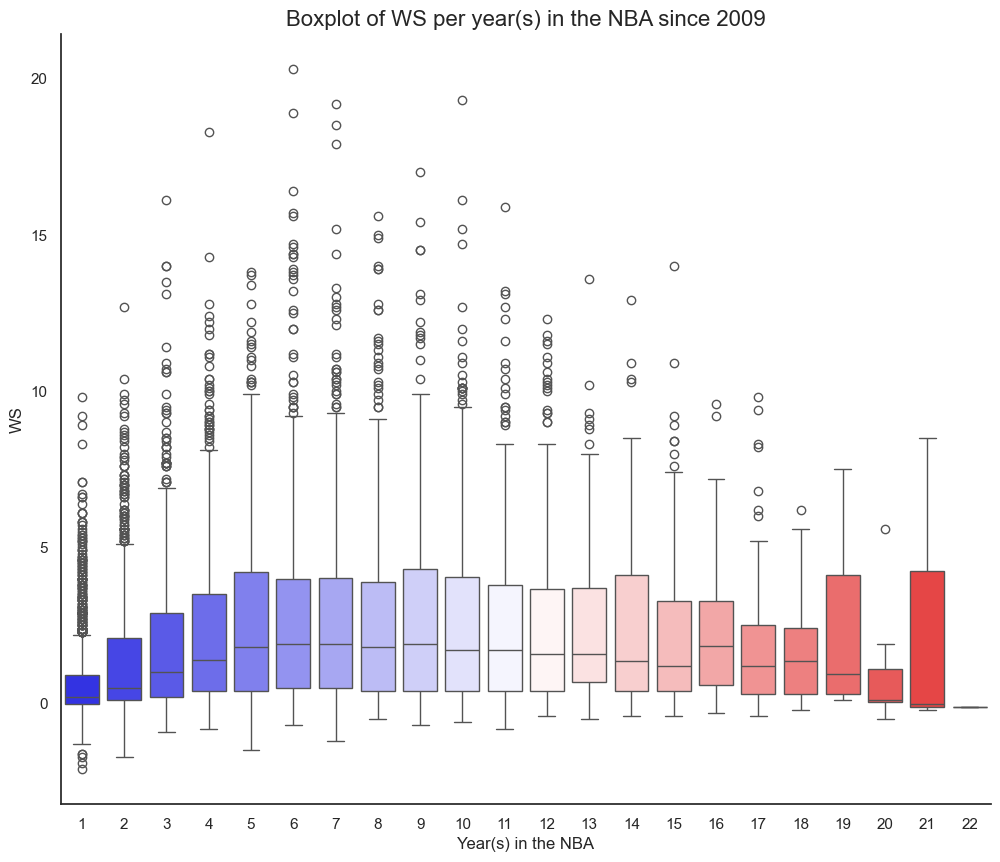

In [230]:
plt.figure(figsize=(12, 10), dpi=100)
sns.boxplot(data=nba_data[nba_data['season'] > 8], x='yrs', y=y, palette='bwr')
plt.xlabel('Year(s) in the NBA')
plt.ylabel(f'{y}')
plt.title(f'Boxplot of {y} per year(s) in the NBA since 2009', size=16)
plt.ylim()
sns.despine()

In [241]:
nba_data['WS/48'].max()

np.float64(2.712)